In [ ]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
import scipy.stats
from sklearn.decomposition import PCA
from adjustText import adjust_text
import warnings
import os

warnings.filterwarnings('ignore')

# ── Global style (matching published figures) ─────────────────────────────
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype']  = 42
mpl.rcParams['text.usetex']  = False
plt.rcParams['font.family']     = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica']

blues   = sns.color_palette('Blues').as_hex()
greens  = sns.color_palette('Greens').as_hex()
reds    = sns.color_palette('Reds').as_hex()
yellows = sns.color_palette('Oranges').as_hex()
purples = sns.color_palette('Purples').as_hex()

greys = sns.color_palette('Greys').as_hex()
teals = sns.color_palette('BuPu').as_hex()
pinks = sns.color_palette('RdPu').as_hex()
browns = sns.color_palette('YlOrBr').as_hex()

In [2]:
BASE = '/Users/kexindong/Documents/GitHub/B-ALL-in-vivo-base-editing/'

dfs = {
    'ABE_OG':     pd.read_csv(BASE + 'LFC-FDR/ABE_OG_LFC_FDR.csv', low_memory=False),
    'CBE_OG':     pd.read_csv(BASE + 'LFC-FDR/CBE_OG_LFC_FDR.csv', low_memory=False),
    'ABE_EPO_T0': pd.read_csv(BASE + 'LFC-FDR/ABE_FC_EPO_T0_LFC_FDR.csv', low_memory=False),
    'CBE_EPO_T0': pd.read_csv(BASE + 'LFC-FDR/CBE_FC_EPO_T0_LFC_FDR.csv', low_memory=False),
    'ABE_EPO_BC': pd.read_csv(BASE + 'LFC-FDR/ABE_FC_EPO_TO_BC_LFC_FDR.csv', low_memory=False),
    'CBE_EPO_BC': pd.read_csv(BASE + 'LFC-FDR/CBE_FC_EPO_TO_BC_LFC_FDR.csv', low_memory=False),
    'ABE_BC_T0':  pd.read_csv(BASE + 'LFC-FDR/ABE_FC_BC_T0_LFC_FDR.csv', low_memory=False),
    'CBE_BC_T0':  pd.read_csv(BASE + 'LFC-FDR/CBE_FC_BC_T0_LFC_FDR.csv', low_memory=False),
}

# Conditions with FDR calculated
conds_og      = ['d15', 'bm', 'spleen', 'men']
conds_focused = ['d15', 'bm', 'spleen']

# Per-replicate raw count columns per condition per screen
rep_cols = {
    'ABE_OG':     {'bm':    ['bonemarrow1','bonemarrow2','bonemarrow3','bonemarrow4','bonemarrow5'],
                   'spleen':['spleen1','spleen2','spleen3','spleen4'],
                   'men':   ['meninges1','meninges2','meninges3','meninges4','meninges5'],
                   'd15':   ['d15_rep1','d15_rep2','d15_rep3']},
    'CBE_OG':     {'bm':    ['bonemarrow1','bonemarrow2','bonemarrow3','bonemarrow4','bonemarrow5'],
                   'spleen':['spleen1','spleen2','spleen3','spleen4'],
                   'men':   ['meninges1','meninges2','meninges3','meninges4','meninges5'],
                   'd15':   ['d15_rep1','d15_rep2','d15_rep3']},
    'ABE_EPO_T0': {'bm':    ['bm1','bm2','bm3','bm4','bm5'],
                   'spleen':['spleen1','spleen2','spleen3','spleen4','spleen5'],
                   'd15':   ['d15_rep1','d15_rep2','d15_rep3']},
    'CBE_EPO_T0': {'bm':    ['bm1','bm3','bm4','bm6','bm7','bm9','bm10'],
                   'spleen':['spleen1','spleen3','spleen4','spleen6','spleen7','spleen9','spleen10'],
                   'd15':   ['d15_rep1','d15_rep2','d15_rep3']},
    'ABE_EPO_BC': {'bm':    ['bm1','bm2','bm3','bm4','bm5'],
                   'spleen':['spleen1','spleen2','spleen3','spleen4','spleen5'],
                   'd15':   ['d15_rep1','d15_rep2','d15_rep3']},
    'CBE_EPO_BC': {'bm':    ['bm1','bm3','bm4','bm6','bm7','bm9','bm10'],
                   'spleen':['spleen1','spleen3','spleen4','spleen6','spleen7','spleen9','spleen10'],
                   'd15':   ['d15_rep1','d15_rep2','d15_rep3']},
    'ABE_BC_T0':  {'bm':    ['bm1','bm2','bm3','bm4','bm5'],
                   'spleen':['spleen1','spleen2','spleen3','spleen4','spleen5'],
                   'd15':   ['d15_rep1','d15_rep2','d15_rep3']},
    'CBE_BC_T0':  {'bm':    ['bm1','bm3','bm4','bm5','bm7','bm8','bm9'],
                   'spleen':['spleen1','spleen3','spleen4','spleen5','spleen7','spleen8','spleen9'],
                   'd15':   ['d15_rep1','d15_rep2','d15_rep3']},
}

# COSMIC cancer gene census
cosmic = pd.read_csv(BASE + 'source-data/Census_allSun Nov 17 02_26_47 2024.csv').fillna('Undefined')
t_dict = {
    'TSG': 'TSG', 'TSG, fusion': 'TSG',
    'Undefined': 'Undefined', 'fusion': 'Undefined',
    'oncogene': 'Oncogene',
    'oncogene, TSG': 'Oncogene/TSG', 'oncogene, TSG, fusion': 'Oncogene/TSG',
    'oncogene, fusion': 'Oncogene',
}
color_dict = {'Oncogene':'tab:red', 'Oncogene/TSG':'tab:purple',
              'TSG':'tab:blue', 'Undefined':'tab:grey'}

def add_cosmic(df):
    gene_col = 'gene_name_h' if 'gene_name_h' in df.columns else 'Gene'
    roles = []
    for v in df[gene_col]:
        sub = cosmic[cosmic['Gene Symbol'] == v]
        roles.append('Undefined' if len(sub)==0 else t_dict.get(sub['Role in Cancer'].values[0], 'Undefined'))
    df = df.copy()
    df['Role in Cancer'] = roles
    df['color'] = [color_dict[r] for r in roles]
    return df

for key in dfs:
    dfs[key] = add_cosmic(dfs[key])

print('Loaded:')
for k, v in dfs.items():
    print(f'  {k}: {len(v)} guides')

Loaded:
  ABE_OG: 1070 guides
  CBE_OG: 13242 guides
  ABE_EPO_T0: 376 guides
  CBE_EPO_T0: 1257 guides
  ABE_EPO_BC: 376 guides
  CBE_EPO_BC: 1257 guides
  ABE_BC_T0: 376 guides
  CBE_BC_T0: 1257 guides


In [3]:
# ── Load count tables ──────────────────────────────────────────────────────
ABE_OG_COUNTS   = pd.read_csv(BASE + 'counts/og/OG_ABE_COUNTS.txt',   sep='\t')
CBE_OG_COUNTS   = pd.read_csv(BASE + 'counts/og/OG_CBE_COUNTS.txt',   sep='\t')
ABE_EPO_COUNTS  = pd.read_csv(BASE + 'counts/focused/FC_ABE_EPO_COUNTS.txt',       sep='\t')
CBE_EPO_COUNTS  = pd.read_csv(BASE + 'counts/focused/FC_CBE_EPO_COUNTS_new.txt',   sep='\t')
ABE_BC_COUNTS   = pd.read_csv(BASE + 'counts/focused/FC_ABE_BC_COUNTS.txt',        sep='\t')
CBE_BC_COUNTS   = pd.read_csv(BASE + 'counts/focused/FC_CBE_BC_COUNTS_new.txt',    sep='\t')

# ── Sample lists used in LFC-FDR (exactly mirroring LFC_FDR_calculation.ipynb) ─
# Only sample columns (no sgRNA/gene/lib annotation columns)

ABE_OG_samps = [
    'bonemarrow1','bonemarrow2','bonemarrow3','bonemarrow4','bonemarrow5',
    'meninges1','meninges2','meninges3','meninges4','meninges5',
    'spleen1','spleen2','spleen3','spleen4',
    'input_rep1','input_rep2','input_rep3',
    'd5_rep1','d5_rep2','d5_rep3',
    'd15_rep1','d15_rep2','d15_rep3',
    'plasmidlib'
]

CBE_OG_samps = [
    'bonemarrow1','bonemarrow2','bonemarrow3','bonemarrow4','bonemarrow5',
    'bonemarrow6','bonemarrow7','bonemarrow8','bonemarrow9','bonemarrow10',
    'meninges1','meninges2','meninges3','meninges4','meninges5',
    'meninges6','meninges7','meninges8','meninges9','meninges10',
    'spleen1','spleen2','spleen3','spleen4','spleen5',
    'spleen6','spleen7','spleen8','spleen9',  # spleen10 excluded
    'input_rep1','input_rep2','input_rep3',
    'd5_rep1','d5_rep2','d5_rep3',
    'd15_rep1','d15_rep2','d15_rep3',
    'plasmidlib'
]

ABE_FC_samps = [
    'bm1','bm2','bm3','bm4','bm5',
    'spleen1','spleen2','spleen3','spleen4','spleen5',
    'd15-rep1','d15-rep2','d15-rep3','d15-rep4','d15-rep5',
    'd5','input','lib'
]

# ABE BC (null): bm2 and spleen2 excluded (abnormal skewing)
ABE_BC_samps = [s for s in ABE_FC_samps if s not in ('bm2', 'spleen2')]

CBE_EPO_samps = [
    'bm1','bm3','bm4','bm6','bm7','bm9','bm10',  # bm2,5,8 excluded
    'spleen1','spleen3','spleen4','spleen6','spleen7','spleen9','spleen10',  # spleen2,5,8 excluded
    'd15-rep1','d15-rep3','d15-rep4','d15-rep5',  # d15-rep2 excluded (abnormal skewing)
    'd5','input','lib'
]

CBE_BC_samps = [
    'bm3','bm4','bm5','bm7','bm9',  # bm1,2,6,8,10 excluded (abnormal skewing)
    'spleen3','spleen4','spleen5','spleen7','spleen9',  # spleen1,2,6,8,10 excluded (abnormal skewing)
    'd15-rep1','d15-rep2','d15-rep3','d15-rep4','d15-rep5',
    'd5','input','lib'
]


In [4]:

# Tissue → color mapping (consistent across screens)
_TISSUE_COLOR = {
    'bonemarrow': '#4393c3',  # blue
    'bm':         '#4393c3',
    'meninges':   '#d6604d',  # red
    'men':        '#d6604d',
    'spleen':     '#74c476',  # green
    'input':      '#969696',  # grey
    'd5':         '#bcbddc',  # light purple
    'd15':        '#756bb1',  # purple
    'plasmidlib': '#252525',  # black
    'lib':        '#252525',
}

def _sample_color(samp):
    for key, col in _TISSUE_COLOR.items():
        if samp.startswith(key):
            return col
    return '#aaaaaa'


def plot_pca(counts_df, samp_cols, screen_name):
    """
    PCA on Spearman correlation between samples.
    Points colored by tissue. Legend shows tissue groups.
    """
    df = counts_df[samp_cols].dropna().copy()
    corr = df.corr(method='spearman')
    pca = PCA(n_components=2)
    Xt = pca.fit_transform(corr)
    var = pca.explained_variance_ratio_
    colors = [_sample_color(s) for s in samp_cols]

    fig, ax = plt.subplots(figsize=(6, 6))
    for i, (x, y) in enumerate(Xt):
        ax.scatter(x, y, c=colors[i], edgecolor='black', s=120, alpha=0.85, zorder=3)
    seen = {}
    for s, col in zip(samp_cols, colors):
        tissue = next((k for k in _TISSUE_COLOR if s.startswith(k)), s)
        if tissue not in seen:
            seen[tissue] = col
    legend_handles = [Patch(facecolor=col, edgecolor='black', label=t) for t, col in seen.items()]
    ax.legend(handles=legend_handles, fontsize=12, loc='best', frameon=False)
    ax.set_xlabel(f'PC1 ({var[0]*100:.1f}%)', fontsize=16)
    ax.set_ylabel(f'PC2 ({var[1]*100:.1f}%)', fontsize=16)
    ax.set_title(f'{screen_name} — PCA on Spearman corr', fontsize=16)
    ax.tick_params(labelsize=16, direction='out', length=6, width=1)
    ax.spines[['top','right']].set_visible(False)
    ax.tick_params(axis='both', which='major', labelsize=16, direction='out', length=6, width=1)
    plt.tight_layout()
    plt.show()


def plot_skew(counts_df, samp_cols, screen_name):
    """
    90/10 skew ratio horizontal barplot, individual samples on y-axis,
    colored by tissue. Red dashed line at x=10 as QC threshold.
    """
    df = counts_df[samp_cols].copy()
    skews, colors = [], []
    for s in samp_cols:
        vals = sorted(df[s].values)
        n = len(vals)
        skews.append(vals[int(0.9*n)] / max(vals[int(0.1*n)], 1))
        colors.append(_sample_color(s))

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.barh(range(len(samp_cols)), skews, color=colors, edgecolor='black', linewidth=0.7)
    ax.set_yticks(range(len(samp_cols)))
    ax.set_yticklabels(samp_cols, fontsize=16)
    ax.axvline(x=10, color='red', linestyle='--', linewidth=1, alpha=0.6, label='QC threshold (10)')
    ax.set_xlabel('90/10 Skew Ratio', fontsize=16)
    ax.set_title(f'{screen_name} — 90/10 Skew Ratio', fontsize=16)
    ax.tick_params(axis='x', labelsize=16, direction='out', length=6, width=1)
    ax.spines[['top','right']].set_visible(False)
    ax.tick_params(axis='both', which='major', labelsize=16, direction='out', length=6, width=1)
    ax.legend(fontsize=12, frameon=False)
    plt.tight_layout()
    plt.show()


def plot_pca_and_skew(counts_df, samp_cols, screen_name):
    """Convenience wrapper: PCA and skew ratio side by side."""
    plot_pca(counts_df, samp_cols, screen_name)
    plot_skew(counts_df, samp_cols, screen_name)


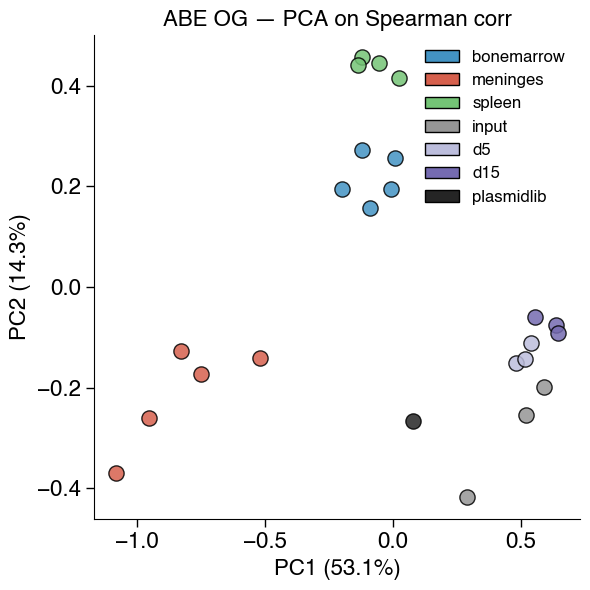

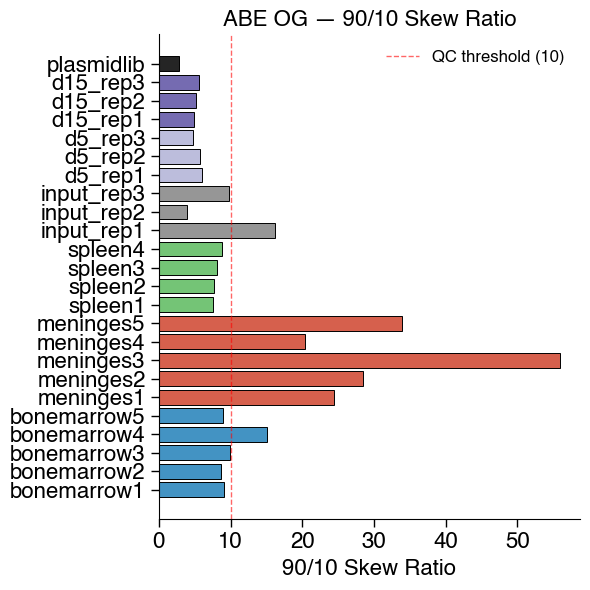

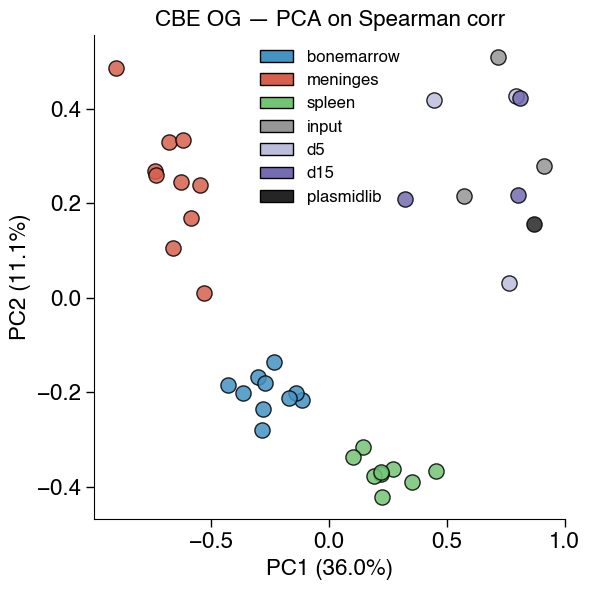

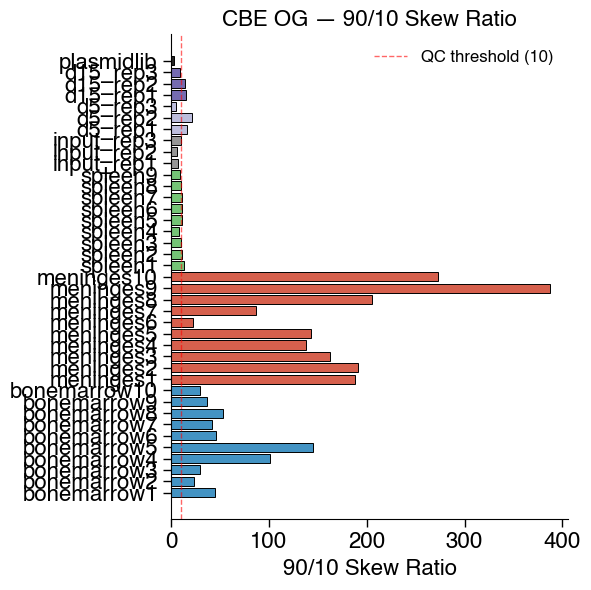

In [5]:
# OG screens
plot_pca_and_skew(ABE_OG_COUNTS, ABE_OG_samps, 'ABE OG')
plot_pca_and_skew(CBE_OG_COUNTS, CBE_OG_samps, 'CBE OG')
# ── Save figure ──────────────────────────────────────────────────────────
# panel = ''  # e.g. '2f'
# fig.savefig(f'figures/{panel}.pdf', bbox_inches='tight')
